# **Live Coding BAB 5 Algoritma Klasifikasi Decision Tree**

- Nama    : Sayyidah Fatimah Azzahra
- NIM     : 235150200111064
- Kelas   : TIF-E

## **1. Import Library**

**Import library standar yang diperlukan, seperti pandas, numpy, dan sebagainya**

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pprint import pprint

## **2. Load Dataset**

**a. Import dataset dari link yang sudah diberikan, dibebaskan menggunakan metode apapun untuk loading dataset.**

In [47]:
df = pd.read_csv('dataset/spaceship_train.csv')

**Tentang Dataset**

The dataset is Spaceship Titanic, a dataset for classification/prediction of whether a passenger was rescued (Transported=True) or not (Transported=False). This dataset is inspired by the Titanic concept but set in outer space. It consists of several columns/features:

*   PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
*   HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
*   CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
*   Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
*   Destination - The planet the passenger will be debarking to.
*   Age - The age of the passenger.
*   VIP - Whether the passenger has paid for special VIP service during the voyage.
*   RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
*   Name - The first and last names of the passenger.
*   Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

**b. *Cetak* dataset**

In [48]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**c. *Deskripsi* dataset**

In [49]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.00000

## **3. Preprocessing**

**a. Ambil indeks fitur numerik dan kategorikal**

In [50]:
df.drop(columns=['PassengerId', 'Cabin', 'Name'], inplace=True)

In [51]:
fitur_numerik = df.select_dtypes(include=['number']).columns
fitur_kategorikal = df.select_dtypes(exclude=['number']).columns

print("Fitur Numerik: ", fitur_numerik)
print("Fitur Kategorikal: ", fitur_kategorikal)

Fitur Numerik:  Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')
Fitur Kategorikal:  Index(['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Transported'], dtype='object')


**b. Transformasi nilai 0 ke NaN untuk data numerik**

In [52]:
df = df.replace(0, np.nan)

**c. Missing Value**

In [53]:
print(df.isnull().sum())

HomePlanet       201
CryoSleep       5656
Destination      182
Age              357
VIP             8494
RoomService     5758
FoodCourt       5639
ShoppingMall    5795
Spa             5507
VRDeck          5683
Transported        0
dtype: int64


Lakukan imputasi data, dengan ketentuan untuk fitur numerik, data NaN diubah menggunakan fungsi **mean** serta untuk fitur kategorikal, data NaN diubah menggunakan fungsi **modus/mode**

In [54]:
def imputasi(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)
    return df

In [55]:
df = imputasi(df)

/var/folders/qj/rbjn75cn3gj4g8pvn3j12c0h0000gn/T/ipykernel_99789/1518405833.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/var/folders/qj/rbjn75cn3gj4g8pvn3j12c0h0000gn/T/ipykernel_99789/1518405833.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].

In [56]:
print("Setelah Imputasi:")
print(df.isnull().sum())

Setelah Imputasi:
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
dtype: int64


**d. Outlier Handling**

In [57]:
def handle_outliers(df):

    for col in fitur_numerik:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    return df

In [58]:
df = handle_outliers(df)

**e. Normalisasi Data**

In [59]:
def minmax_normalization(column):
    return (column - column.min()) / (column.max() - column.min())

In [60]:
for column in fitur_numerik:
    df[column] = minmax_normalization(df[column])

**b. Lakukan label encoding untuk fitur/kolom kategorikal!**

In [61]:
label_encoder = LabelEncoder()
df = df.apply(label_encoder.fit_transform)

**c. Ubah kolom target, yang awalnya boolean menjadi integer**

In [62]:
df['Transported'] = df['Transported'].astype(int)

## **4. Split Dataset**

Ambil sample data sebanyak 3000 dengan memperhatikan distribusi kelas.
Lalu pisahkan dataset menjadi data latih dan data uji

In [63]:
sampled_df, _ = train_test_split(df, train_size=3000, stratify=df['Transported'], random_state=42)

In [64]:
data_latih, data_uji = train_test_split(sampled_df,test_size=0.2,random_state=42)
data_latih = data_latih.reset_index(drop=True)
data_uji = data_uji.reset_index(drop=True)

## **5. GINI dan Information Gain**

**a. Fungsi Hitung Gini**

Buat fungsi untuk menghitung nilai gini dari sebuah variabel.

In [65]:
def hitung_gini (kolom_kelas):
  elemen,banyak = np. unique(kolom_kelas, return_counts = True)
  nilai_gini = 1 - np.sum([(banyak[i]/np.sum(banyak))**2 for i in range(len(elemen))])
  return nilai_gini

**b. Fungsi Gini Split**

Buat fungsi untuk untuk menghitung nilai Gini keseluruhan dari sebuah variabel.

In [66]:
def hitung_gini_split(data, nama_fitur_split, nama_fitur_kelas):
  nilai,banyak= np.unique(data[nama_fitur_split],return_counts=True)
  gini_split = np.sum([(banyak[i] / np.sum(banyak)) * hitung_gini(data.where(data[nama_fitur_split]==nilai[i]).dropna() [nama_fitur_kelas]) for i in range(len(nilai))])
  return gini_split

**c. Hitung Entropy**

buat fungsi untuk menghitung entropy

In [67]:
import math

In [68]:
'''
entropy(p) = − SUM (Pi * log(Pi) )
'''

def hitung_entropy(kolom_kelas):
  class_counts = kolom_kelas.value_counts()
  total_samples = len(kolom_kelas)
  entropy = 0
  for count in class_counts:
    p_i = count / total_samples
    entropy -= p_i * math.log2(p_i)
  return entropy

**d. Fungsi Information Gain**

Buat fungsi untuk menghitung information gain

In [69]:
'''
gain(D, A) = entropy(D)−􏰋 SUM ( |Di| / |D| * entropy(Di) )
'''

def information_gain(data, nama_fitur_split, nama_fitur_kelas):
  total_entropy = hitung_entropy(data[nama_fitur_kelas])
  values = data[nama_fitur_split].unique()
  weighted_entropy = 0
  total_samples = len(data)

  for value in values:
    subset = data[data[nama_fitur_split] == value]
    subset_entropy = hitung_entropy(subset[nama_fitur_kelas])
    weighted_entropy += (len(subset) / total_samples) * subset_entropy

  information_gain = total_entropy - weighted_entropy

  return information_gain

## **6. Model Decision Tree**

**a. Fungsi Tree**

Buat fungsi untuk membentuk sebuah tree.

In [70]:
import numpy as np

def build_tree(data, data_awal, daftar_fitur, nama_fitur_kelas, metode, kelas_parent_node=None):
    # Jika hanya ada satu kelas pada data
    if len(np.unique(data[nama_fitur_kelas])) <= 1:
        return np.unique(data[nama_fitur_kelas])[0]

    # Jika data kosong
    elif len(data) == 0:
        return np.unique(data_awal[nama_fitur_kelas])[
            np.argmax(np.unique(data_awal[nama_fitur_kelas], return_counts=True)[1])
        ]

    # Jika tidak ada fitur yang tersisa
    elif len(daftar_fitur) == 0:
        return kelas_parent_node

    else:
        # Tentukan kelas parent node berdasarkan kelas dengan frekuensi tertinggi
        kelas_parent_node = np.unique(data[nama_fitur_kelas])[
            np.argmax(np.unique(data[nama_fitur_kelas], return_counts=True)[1])
        ]

        # Hitung impurity untuk setiap fitur berdasarkan metode
        if metode == "gini":
            nilai_split = [hitung_gini_split(data, fitur, nama_fitur_kelas) for fitur in daftar_fitur]
        elif metode == "information_gain":
            nilai_split = [information_gain(data, fitur, nama_fitur_kelas) for fitur in daftar_fitur]
        else:
            raise ValueError("Metode harus 'gini' atau 'information_gain'")

        # Pilih fitur terbaik berdasarkan metode
        if metode == "gini":
            index_fitur_terbaik = np.argmin(nilai_split)
        elif metode == "information_gain":
            index_fitur_terbaik = np.argmax(nilai_split)

        fitur_terbaik = daftar_fitur[index_fitur_terbaik]

        # Buat node tree
        tree = {fitur_terbaik: {}}

        # Buat salinan daftar fitur tanpa fitur yang sudah digunakan
        daftar_fitur_baru = [i for i in daftar_fitur if i != fitur_terbaik]

        # Rekursi untuk setiap nilai fitur terbaik
        for nilai in np.unique(data[fitur_terbaik]):
            sub_data = data[data[fitur_terbaik] == nilai]
            subtree = build_tree(sub_data, data_awal, daftar_fitur_baru, nama_fitur_kelas, metode, kelas_parent_node)
            tree[fitur_terbaik][nilai] = subtree

        return tree

**b. Buat Tree**

Buat 2 tree dengan menggunakan data latih dengan metode gini dan information_gain.

In [71]:
daftar_fitur = list(data_latih.columns[:-1]) 
nama_fitur_kelas = data_latih.columns[-1]
kelas_parent_node = 0

# Metode Gini
tree_1 = build_tree(data_latih, sampled_df, daftar_fitur, nama_fitur_kelas, metode="gini", kelas_parent_node=kelas_parent_node)

# Metode Information Gain
tree_2 = build_tree(data_latih, sampled_df, daftar_fitur, nama_fitur_kelas, metode="information_gain", kelas_parent_node=kelas_parent_node)

**c. Tampilkan Tree**

print tree yang telah dibuat

In [72]:
pprint(tree_1)

{'Spa': {np.int64(0): {'FoodCourt': {np.int64(0): {'Age': {np.int64(12): {'Destination': {np.int64(0): {'HomePlanet': {np.int64(0): {'CryoSleep': {np.int64(0): {'VIP': {np.int64(0): {'RoomService': {np.int64(0): {'ShoppingMall': {np.int64(0): {'VRDeck': {np.int64(0): np.int64(0)}}}}}}}}}}}},
                                                                                          np.int64(2): np.int64(0)}},
                                                           np.int64(13): np.int64(0),
                                                           np.int64(15): np.int64(0),
                                                           np.int64(16): np.int64(0),
                                                           np.int64(17): {'Destination': {np.int64(0): np.int64(0),
                                                                                          np.int64(2): {'VRDeck': {np.int64(0): np.int64(0),
                                                                          

In [73]:
pprint(tree_2)

{'Spa': {np.int64(0): {'FoodCourt': {np.int64(0): {'Age': {np.int64(12): {'Destination': {np.int64(0): {'HomePlanet': {np.int64(0): {'CryoSleep': {np.int64(0): {'VIP': {np.int64(0): {'RoomService': {np.int64(0): {'ShoppingMall': {np.int64(0): {'VRDeck': {np.int64(0): np.int64(0)}}}}}}}}}}}},
                                                                                          np.int64(2): np.int64(0)}},
                                                           np.int64(13): np.int64(0),
                                                           np.int64(15): np.int64(0),
                                                           np.int64(16): np.int64(0),
                                                           np.int64(17): {'Destination': {np.int64(0): np.int64(0),
                                                                                          np.int64(2): {'VRDeck': {np.int64(0): np.int64(0),
                                                                          

**c. Fungsi Prediksi**

Buat fungsi untuk memprediksi kelas dari data uji

In [74]:
def prediksi(data_uji,tree):
    for key in list(data_uji.keys()):
        if key in list(tree.keys()):
            try:
                hasil = tree[key][data_uji[key]]
            except:
                return 1
            hasil = tree[key][data_uji[key]]
            if isinstance(hasil,dict):
                return prediksi(data_uji,hasil)
            else:
                return hasil

**d. Pengujian**

Lakukan pengujian dengan menggunakan data uji secara looping dan disimpan dalam sebuah list.

In [75]:
data_uji_dict = data_uji. iloc[:,:-1].to_dict(orient = "records")

In [76]:
nama_fitur_kelas_uji = data_uji.columns[-1]

In [77]:
hasil_prediksi_gini = []
hasil_prediksi_information_gain = []

In [78]:
for i in range(len(data_uji)):
    hasil_prediksi_gini.append(prediksi(data_uji.iloc[i], tree_1))
    hasil_prediksi_information_gain.append(prediksi(data_uji.iloc[i], tree_2))

In [79]:
hasil_prediksi_gini = np.array(hasil_prediksi_gini)
hasil_prediksi_information_gain = np.array(hasil_prediksi_information_gain)
actual_class = np.array(data_uji[nama_fitur_kelas_uji])

Tampilkan hasil prediksi yang benar, salah, dan total data uji.

In [80]:
print("Prediksi Tree GINI")
print("------------------------")
print("Total prediksi benar:", sum(hasil_prediksi_gini == actual_class))
print("Total prediksi salah:", sum(hasil_prediksi_gini != actual_class))
print("Akurasi: ", sum(hasil_prediksi_gini == actual_class) / len(data_uji))
print("Total data: ", len(data_uji))

Prediksi Tree GINI
------------------------
Total prediksi benar: 323
Total prediksi salah: 277
Akurasi:  0.5383333333333333
Total data:  600


In [81]:
print("\nPrediksi Tree Information Gain")
print("------------------------")
print("Total prediksi benar:", sum(hasil_prediksi_information_gain == actual_class))
print("Total prediksi salah:", sum(hasil_prediksi_information_gain != actual_class))
print("Akurasi: ", sum(hasil_prediksi_information_gain == actual_class) / len(data_uji))
print("Total data: ", len(data_uji))


Prediksi Tree Information Gain
------------------------
Total prediksi benar: 334
Total prediksi salah: 266
Akurasi:  0.5566666666666666
Total data:  600


**e. Pertanyaan**
1. Dari antara kedua metode tersebut, metode mana yang memiliki akurasi terbaik? Apa alasannya?
2. Sebutkan kelebihan dan kekurangan masing-masing metode

**JAWAB**
1. Dari hasil implementasi, metode Information Gain memberikan akurasi yang lebih baik karena ia mempertimbangkan entropi (ketidakpastian) secara eksplisit dan mengukur seberapa banyak informasi yang diperoleh setelah pemisahan data. Selain itu, Information Gain juga memilih split yang memaksimalkan pengurangan entropi, sehingga bisa menghasilkan tree yang lebih dalam dan efektif. 
2. Kelebihan Gini Impurity adalah ia lebih cepat dan efisien dalam perhitungannya. Namun, ia kurang sensitif terhadap perbedaan frekuensi kelas dalam data pelatihan. Sementara itu, Information Gain lebih sensitif terhadap perbedaan frekuensi kelas, sehingga bisa lebih cocok untuk data dengan kelas yang bersifat imbalanced secara signifikan.

## **7. XGBoost**

Lakukan klasifikasi menggunakan XGBoost

**a. Import Library**

In [82]:
import xgboost as xgb
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

**b. Pisahkan Fitur dengan Label**

In [83]:
X, y = sampled_df.drop('Transported', axis=1), sampled_df['Transported']

**c. Split Data**

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**d. Buat Model/Classifier XGB**

In [85]:
model = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')

**e. Pengujian**

In [86]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2,
              n_jobs=None, num_parallel_tree=None, ...)

In [87]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 0.67


**f. Feature Importance XGB**

Lakukan Visualisasi Feature Importance menggunakan fungsi yang disediakan di XGB.

<Figure size 1000x600 with 0 Axes>

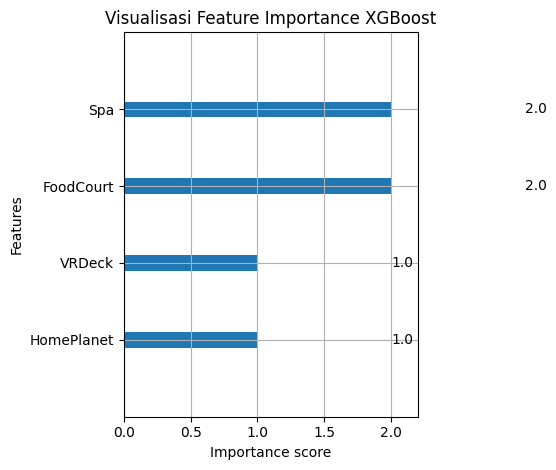

In [88]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model)
plt.title('Visualisasi Feature Importance XGBoost')
plt.tight_layout()
plt.show()

***Pertanyaan***

Visualisasi apa yang diberikan dan jelaskan!

Jawaban:

Visualisasi yang ditampilkan adalah diagram batang horizontal yang mengurutkan fitur berdasarkan tingkat kepentingannya dalam model. Batang yang lebih panjang menunjukkan fitur yang lebih berpengaruh dalam pengambilan keputusan model.

**f. Hyperparameter Tuning**

Hyperparameter tuning adalah proses mencari kombinasi terbaik dari parameter eksternal dalam model machine learning agar model memiliki performa terbaik. Salah satu metodenya adalah GridSearch, dimana metode ini mencoba semua kombinasi dari parameter yang diberikan dan memilih yang terbaik berdasarkan metrik evaluasi misalnya akurasi .

In [89]:
# Daftar hyperparameter yang akan diuji
n_estimators_list = [100, 200, 300]
max_depth_list = [3, 5, 7]
learning_rate_list = [0.01, 0.1, 0.2]

# Variabel untuk menyimpan hasil terbaik
best_params = None
best_accuracy = 0

# Looping untuk mencoba semua kombinasi hyperparameter
for n in n_estimators_list:
    for depth in max_depth_list:
        for lr in learning_rate_list:
            # Inisialisasi model dengan hyperparameter saat ini
            model = xgb.XGBClassifier(n_estimators=n, max_depth=depth, learning_rate=lr)

            # Latih model
            model.fit(X_train, y_train)

            # Evaluasi model
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)

            # Simpan kombinasi terbaik
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {'n_estimators': n, 'max_depth': depth, 'learning_rate': lr}

            print(f"n_estimators={n}, max_depth={depth}, learning_rate={lr} → Accuracy: {accuracy:.4f}")

# Print hasil terbaik
print("\nBest Parameters:", best_params)
print("Best Accuracy:", best_accuracy)


n_estimators=100, max_depth=3, learning_rate=0.01 → Accuracy: 0.6917
n_estimators=100, max_depth=3, learning_rate=0.1 → Accuracy: 0.7100
n_estimators=100, max_depth=3, learning_rate=0.2 → Accuracy: 0.7050
n_estimators=100, max_depth=5, learning_rate=0.01 → Accuracy: 0.7050
n_estimators=100, max_depth=5, learning_rate=0.1 → Accuracy: 0.7117
n_estimators=100, max_depth=5, learning_rate=0.2 → Accuracy: 0.7000
n_estimators=100, max_depth=7, learning_rate=0.01 → Accuracy: 0.7167
n_estimators=100, max_depth=7, learning_rate=0.1 → Accuracy: 0.6933
n_estimators=100, max_depth=7, learning_rate=0.2 → Accuracy: 0.6867
n_estimators=200, max_depth=3, learning_rate=0.01 → Accuracy: 0.7033
n_estimators=200, max_depth=3, learning_rate=0.1 → Accuracy: 0.7000
n_estimators=200, max_depth=3, learning_rate=0.2 → Accuracy: 0.6867
n_estimators=200, max_depth=5, learning_rate=0.01 → Accuracy: 0.7083
n_estimators=200, max_depth=5, learning_rate=0.1 → Accuracy: 0.6967
n_estimators=200, max_depth=5, learning_rat

***Pertanyaan***

Apa manfaat dan kelemahan dari Hyperparameter Tuning menggunakan GridSearch?

Jawaban:
Utamanya, kita bisa mengeksplorasi lebih banyak kombinasi hyperparameter yang mungkin secara otomatis dengan jaminan hasil yang optimal. Namun, untuk grid yang besar, komputasinya mahal dan memakan waktu. Selain itu, kita harus menentukan rentang hyperparameter yang akan kita eksplorasi dan ada risiko terjadi overfitting pada data validasi yang kita gunakan.

Dalam kasus saya, hasil akurasi model meningkat dari 67% menjadi 71% dengan hyperparameter tuning menggunakan GridSearch.